In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize']=(12,6)

In [3]:
columns = ['unit_number','time_cycles','op_setting_1','op_setting_2','op_setting_3'] + [f'sensor_{i}' for i in range(1,22)]

In [4]:
train_df = pd.read_csv('train_FD001.txt',sep=r'\s+',header = None,names=columns)

In [5]:
train_df.columns.tolist()

['unit_number',
 'time_cycles',
 'op_setting_1',
 'op_setting_2',
 'op_setting_3',
 'sensor_1',
 'sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_5',
 'sensor_6',
 'sensor_7',
 'sensor_8',
 'sensor_9',
 'sensor_10',
 'sensor_11',
 'sensor_12',
 'sensor_13',
 'sensor_14',
 'sensor_15',
 'sensor_16',
 'sensor_17',
 'sensor_18',
 'sensor_19',
 'sensor_20',
 'sensor_21']

In [6]:
max_cycles = train_df.groupby('unit_number')['time_cycles'].max().reset_index()
max_cycles.columns = ['unit_number', 'max_cycle']

train_df = train_df.merge(max_cycles, on='unit_number', how='left')
train_df['RUL'] = train_df['max_cycle'] - train_df['time_cycles']
train_df = train_df.drop('max_cycle', axis=1)




In [7]:
train_df.shape

(20631, 27)

In [8]:
train_df.head()

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


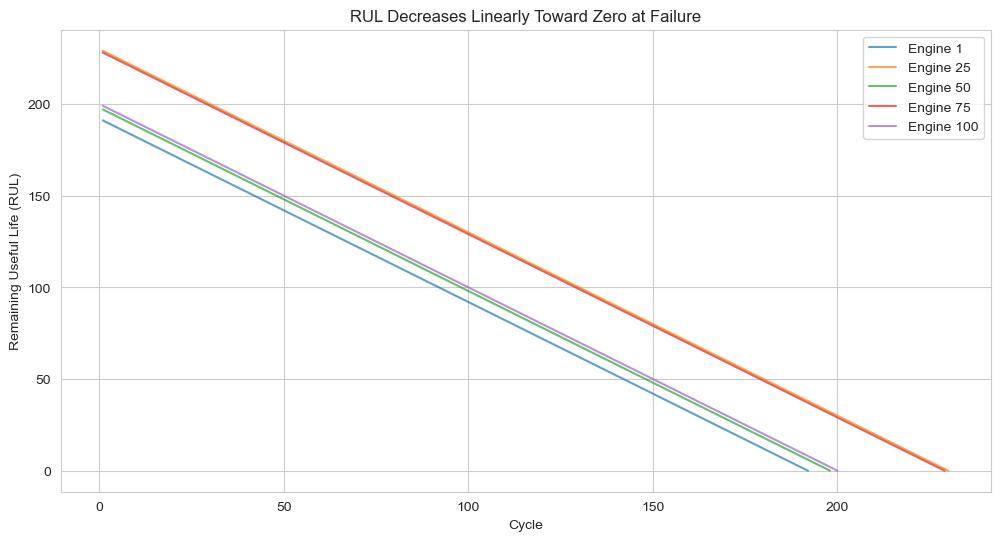

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

for engine_id in [1, 25, 50, 75, 100]:
    engine = train_df[train_df['unit_number'] == engine_id]
    ax.plot(engine['time_cycles'], engine['RUL'], 
            label=f'Engine {engine_id}', alpha=0.7)

ax.set_xlabel('Cycle')
ax.set_ylabel('Remaining Useful Life (RUL)')
ax.set_title('RUL Decreases Linearly Toward Zero at Failure')
ax.legend()

import os
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/rul_curves.png', dpi=150, bbox_inches='tight')
plt.show()

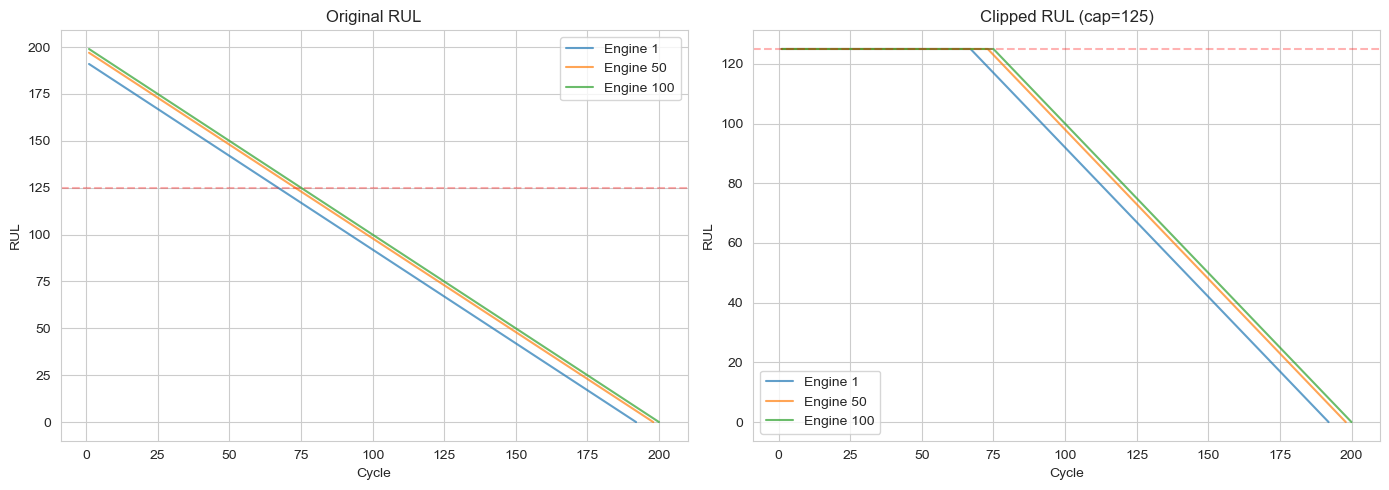

In [10]:
RUL_CAP = 125
train_df['RUL_clipped'] = train_df['RUL'].clip(upper=RUL_CAP)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for engine_id in [1, 50, 100]:
    engine = train_df[train_df['unit_number'] == engine_id]
    axes[0].plot(engine['time_cycles'], engine['RUL'], 
                 label=f'Engine {engine_id}', alpha=0.7)
    axes[1].plot(engine['time_cycles'], engine['RUL_clipped'], 
                 label=f'Engine {engine_id}', alpha=0.7)

axes[0].set_title('Original RUL')
axes[1].set_title('Clipped RUL (cap=125)')
for ax in axes:
    ax.set_xlabel('Cycle')
    ax.set_ylabel('RUL')
    ax.legend()
    ax.axhline(125, color='red', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/rul_clipping_comparison.png', dpi=150)
plt.show()

#### Train val split with zero overlap to overcome Data Leakage

In [14]:
unique_engines = train_df['unit_number'].unique()
print(f"Total engines: {len(unique_engines)}")

np.random.seed(42)
np.random.shuffle(unique_engines)

split_idx = int(0.8 * len(unique_engines))
train_engines = unique_engines[:split_idx]
val_engines = unique_engines[split_idx:]

train_data = train_df[train_df['unit_number'].isin(train_engines)].copy()
val_data = train_df[train_df['unit_number'].isin(val_engines)].copy()

print(f"Training engines: {len(train_engines)} | rows: {len(train_data)}")
print(f"Validation engines: {len(val_engines)} | rows: {len(val_data)}")

# Verify no overlap
overlap = set(train_data['unit_number']) & set(val_data['unit_number'])
assert len(overlap) == 0


Total engines: 100
Training engines: 80 | rows: 16340
Validation engines: 20 | rows: 4291


## Engine-level split

In [16]:
from sklearn.model_selection import train_test_split

train_wrong, val_wrong = train_test_split(train_df, test_size=0.2, random_state=42)

wrong_train_engines = set(train_wrong['unit_number'])
wrong_val_engines = set(val_wrong['unit_number'])
overlap_wrong = wrong_train_engines & wrong_val_engines

print(f"'Wrong' train engines: {len(wrong_train_engines)}")
print(f"'Wrong' val engines: {len(wrong_val_engines)}")
print(f"Overlap (data leakage): {len(overlap_wrong)} engines")


'Wrong' train engines: 100
'Wrong' val engines: 100
Overlap (data leakage): 100 engines


In [28]:
import os
os.makedirs('data/processed', exist_ok=True)

train_data.to_csv('data/processed/train_with_rul.csv', index=False)
val_data.to_csv('data/processed/val_with_rul.csv', index=False)

# Verify whether it is saved or not
test_load = pd.read_csv('data/processed/train_with_rul.csv')
test_load.shape

(16340, 28)

In [22]:
train_data

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL,RUL_clipped
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189,125
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188,125
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187,125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,4,4
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,3,3
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,2,2
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,1,1


In [23]:
val_data

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL,RUL_clipped
192,2,1,-0.0018,0.0006,100.0,518.67,641.89,1583.84,1391.28,14.62,...,8137.72,8.3905,0.03,391,2388,100.0,38.94,23.4585,286,125
193,2,2,0.0043,-0.0003,100.0,518.67,641.82,1587.05,1393.13,14.62,...,8131.09,8.4167,0.03,392,2388,100.0,39.06,23.4085,285,125
194,2,3,0.0018,0.0003,100.0,518.67,641.55,1588.32,1398.96,14.62,...,8140.58,8.3802,0.03,391,2388,100.0,39.11,23.4250,284,125
195,2,4,0.0035,-0.0004,100.0,518.67,641.68,1584.15,1396.08,14.62,...,8140.44,8.4018,0.03,391,2388,100.0,39.13,23.5027,283,125
196,2,5,0.0005,0.0004,100.0,518.67,641.73,1579.03,1402.52,14.62,...,8136.67,8.3867,0.03,390,2388,100.0,39.18,23.4234,282,125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19006,93,151,0.0034,-0.0002,100.0,518.67,643.43,1598.68,1436.78,14.62,...,8138.51,8.5096,0.03,397,2388,100.0,38.40,23.0142,4,4
19007,93,152,0.0014,0.0001,100.0,518.67,643.59,1597.97,1426.50,14.62,...,8133.67,8.5198,0.03,395,2388,100.0,38.46,23.1200,3,3
19008,93,153,0.0024,0.0000,100.0,518.67,643.77,1599.57,1428.83,14.62,...,8143.45,8.5095,0.03,397,2388,100.0,38.57,23.1388,2,2
19009,93,154,-0.0003,-0.0001,100.0,518.67,643.74,1604.81,1438.41,14.62,...,8142.49,8.5313,0.03,396,2388,100.0,38.30,23.0633,1,1


In [24]:
test_load

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL,RUL_clipped
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189,125
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188,125
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187,125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16335,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,4,4
16336,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,3,3
16337,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,2,2
16338,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,1,1


In [26]:
del test_load
del train_wrong, val_wrong
del max_cycles